In [215]:
import numpy as np
import scipy
import pandas as pd
import thinkbayes

from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

In [216]:
df = pd.read_csv("showcases.2011.csv").T
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)
df = df.loc[:, df.columns.notna()]
df = df.astype(float)
df1 = df.copy()

df = pd.read_csv("showcases.2012.csv").T
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)
df = df.loc[:, df.columns.notna()]
df = df.astype(float)
df2 = df.copy()

df3 = pd.concat([df1, df2], axis=0, ignore_index=True)

df3.head()

Unnamed: 0,Showcase 1,Showcase 2,Bid 1,Bid 2,Difference 1,Difference 2
0,50969.0,45429.0,42000.0,34000.0,8969.0,11429.0
1,21901.0,34061.0,14000.0,59900.0,7901.0,-25839.0
2,32815.0,53186.0,32000.0,45000.0,815.0,8186.0
3,44432.0,31428.0,27000.0,38000.0,17432.0,-6572.0
4,24273.0,22320.0,18750.0,23000.0,5523.0,-680.0


In [217]:
showcase1 = df3["Showcase 1"].dropna().values
showcase2 = df3["Showcase 2"].dropna().values

diff1 = df3["Difference 1"].to_numpy()
diff2 = df3["Difference 2"].to_numpy()

bid1 = df3["Bid 1"].dropna().values
bid2 = df3["Bid 2"].dropna().values

CDF1(0) = 0.246
CDF2(0) = 0.291


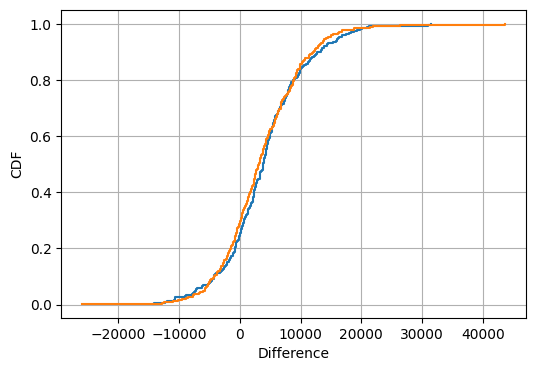

In [218]:
# データを昇順に並べる
x1 = np.sort(diff1)
x2 = np.sort(diff2)

# 累積確率
cdf1 = np.arange(1, len(x1)+1)/len(x1)
cdf2 = np.arange(1, len(x2)+1)/len(x2)

# Difference
n1 = np.searchsorted(x1, 0, side='right')
cdf1_at0 = n1/len(x1)

n2 = np.searchsorted(x2, 0, side="right")
cdf2_at0 = n2/len(x2)

print(f"CDF1(0) = {cdf1_at0:.3f}")
print(f"CDF2(0) = {cdf2_at0:.3f}")

# 
plt.figure(figsize=(6,4))
plt.step(x1, cdf1, where="post")
plt.step(x2, cdf2, where=("post"))
plt.xlabel("Difference")
plt.ylabel("CDF")
plt.grid(True)

In [219]:
class Player(object):
    """Represents a player on The Price is Right."""

    n = 101
    price_xs = np.linspace(0, 75000, n)

    def __init__(self, prices, bids, diffs):
        """Construct the Player.
        Prices: sequence of prices
        bids: sequence of bids
        diffs: sequence of underness (negative means over)
        """

        self.pdf_price = thinkbayes.EstimatedPdf(prices)
        self.cdf_diff = thinkbayes.MakeCdfFromList(diffs)

        mu = 0
        sigma = np.std(diffs)
        self.pdf_error = thinkbayes.GaussianPdf(mu, sigma)

        self.pdf_error_kde = thinkbayes.EstimatedPdf(diffs)

    def ErrorDensity(self, error):
        """Density of the given error in the distribution of error.
        与えられた誤差の、誤差分布における密度を返す。
        error: how much the bid in under the actual price
        """

        return self.pdf_error.Density(error)

    def PmfPrice(self):
        """Return a new pmf of prices.
        価格についての新しいpmfを返す。
        
        A discrete version of the estimated Pdf.
        """

        return self.pdf_price.MakePmf(self.price_xs)

    def CdfDiff(self):
        """Return a reference to the Cdf of differences (underness).
        差のCDF（アンダーネス）への参照を返す。
        """

        return self.cdf_diff

    def ErrorDensityGauss(self, error):
        """Density of the given error in the distribution of error.
        与えられた誤差の、誤差分布における密度を返す。
        
        error: how much the bid is under the actual price
        """
        return self.pdf_error_gauss.Density(error)

    def ErrorDensityKDE(self, error):
        return self.pdf_error_kde.Density(error)

    def MakeBeliefs(self, guess):
        """Makes a posterior distribution based on estimated price.
        確定した価格に基づいて事後分布を作る。
        Sets attributes prior and posterior.

        guess: what the player thinks the showcase is worth
        """

        pmf = self.PmfPrice()
        self.prior = Price(pmf, self, name='prior')
        self.posterior = self.prior.Copy(name='posterior')
        self.posterior.Update(guess)

    def OptimalBid(self, guess, opponent):
        """Computes the bid that mazimizes expected return.
        期待利益を最大にする入札額を計算する。

        guess: what the player thinks the showcase is worth
        oppnent: Player

        returns: (optimal bid, expected gain)
        """

        self.MakeBeliefs(guess)
        calc = GainCalculator(self, opponent)
        bids, gains = calc.ExpectedGains()
        gain, bid = max(zip(gains, bids))

        return bid, gain

    def ProbOverbid(self):
        """Returns the probability this player overbids.
        このプレーヤーが入札しすぎる確率を返す。
        """

        return self.cdf_diff.Prob(-1)
    
    def ProbWorseThan(self, diff):
        """Probability this player's diff is greater than the given diff.
        このプレーヤーの差が、与えられた差より大きくなる確率。
        
        diff: how much the opponent is off by (always positive)
        """

        return 1 - self.cdf_diff.Prob(diff)

In [238]:
class Price(thinkbayes.Suite):
    """Represents hypotheses about the price of a showcase."""

    def __init__(self, pmf, player, name=""):
        """Constructs the suite.
        
        pmf: prior distribution of price
        player: player object
        name: string
        """
        print(type(pmf))
        thinkbayes.Suite.__init__(self, pmf, name=name)
        self.player = player

    def Likelihood(self, data, hypo):
        """Computes the likelihood of the data under the hypothesis.
        
        hypo: actual price
        data: the contestant's guess
        """

        price = hypo
        guess = data

        error = price - guess
        like = self.player.ErrorDensity(error)

        return like


In [250]:
class GainCalculator(object):
    """Estimates coputation of expected gain.
    期待値利益を計算する"""

    def __init__(self, player, opponent):
        """Constructs the calculat.
        player: Player
        opponent: Player
        """

        self.player = player
        self.opponent = opponent

    def ExpectedGains(self, low=0, high=75000, n=101):
        """"Computes expected gains for a range of bids.
        入札額の範囲について期待利益を計算する
        low: low bid
        high: high bid
        n: number of bids to evaluates
        returns: tuple (sequence of bids, sequence of gains)タプル
        """

        bids = np.linspace(low, high, n)
        gains = [self.ExpectedGain(bid) for bid in bids]
        return bids, gains

    def ExpectedGain(self, bid):
        """Computes the expected return of a given bid.
        与えられた入札額に対する期待利益を計算する。
        bid: your bid
        """
        suite = self.player.posterior
        total = 0
        for price, prob in sorted(suite.Items()):
            gain = self.Gain(bid, price)
            total += prob * gain
        return total

    def Gain(self, bid, price):
        """Computes the return of a bid, given the actual price.
        実際の価格が与えられた時の、入札による利益を計算する
        bid: number
        price: actual price
        """

        # if you overbid, you get nothing
        if bid > price:
            return 0

        #otherwise compute the probability of winning
        diff = price - bid
        prob = self.ProbWin(diff)

        print(diff,prob)

        # if you are within $250, you win both showcases
        if diff <= 250:
            return 2 * price * prob
        else:
            return price * prob

    def ProbWin(self, diff):
        """Computes the probability of winning for a given diff.
        与えられた価格差に対して、かつ確率を計算する
        diff: how much your bid was off by
        """
        prob = (self.opponent.ProbOverbid() +
                self.opponent.ProbWorseThan(diff))
        return prob
        

In [251]:
player1 = Player(showcase1, bid1, diff1)
player2 = Player(showcase2, bid2, diff2)

In [252]:
player1.MakeBeliefs(guess=20000)
player2.MakeBeliefs(guess=40000)

<class 'thinkbayes.Pmf'>
<class 'thinkbayes.Pmf'>


In [253]:
pmf1 = player1.PmfPrice()

print(type(pmf1.Items()))



<class 'dict_items'>


In [254]:
mean1 = player1.posterior.Mean()
mean2 = player2.posterior.Mean()

mle1 = player1.posterior.MaximumLikelihood()
mle2 = player2.posterior.MaximumLikelihood()

print(mean1, mean2)
print(mle1, mle2)

25096.41181620624 35641.21686971352
24000.0 35250.0


Posterior mean = 25096.41181620626
Posterior MLE  = 24000.0


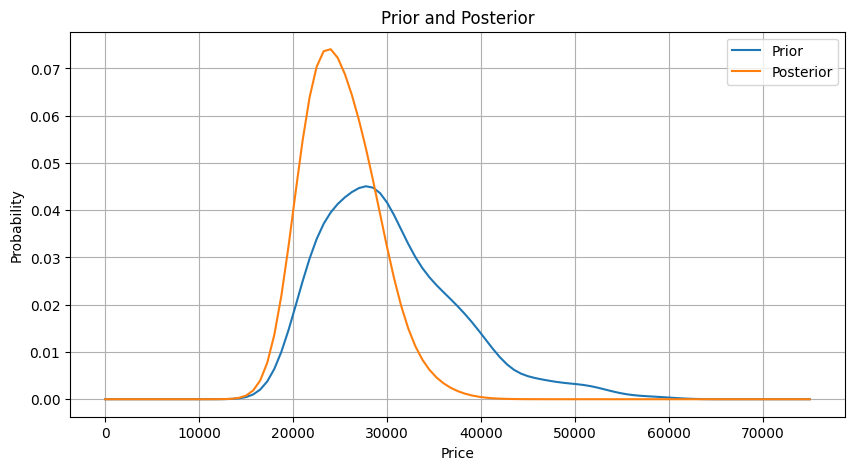

In [255]:
# x軸：価格
xs = player1.price_xs

# Prior
prior_y = np.array([
    player1.prior.Prob(price).item()
    for price in xs
])

posterior_x, posterior_y = zip(*player1.posterior.Items())

# 平均値
posterior_mean = np.sum(xs * posterior_y)

# MLE（最大確率の価格）
posterior_mle = xs[np.argmax(posterior_y)]

print("Posterior mean =", posterior_mean)
print("Posterior MLE  =", posterior_mle)


plt.figure(figsize=(10, 5))

plt.plot(xs, prior_y, label="Prior")
plt.plot(xs, posterior_y, label="Posterior")

plt.xlabel("Price")
plt.ylabel("Probability")
plt.title("Prior and Posterior")
plt.legend()
plt.grid()
plt.show()

In [256]:
print('Player 1 prior mle', player1.prior.MaximumLikelihood())
print('Player 2 prior mle', player2.prior.MaximumLikelihood())
print('Player 1 mean', player1.posterior.Mean())
print('Player 2 mean', player2.posterior.Mean())
print('Player 1 mle', player1.posterior.MaximumLikelihood())
print('Player 2 mle', player2.posterior.MaximumLikelihood())

Player 1 prior mle 27750.0
Player 2 prior mle 27750.0
Player 1 mean 25096.41181620624
Player 2 mean 35641.21686971352
Player 1 mle 24000.0
Player 2 mle 35250.0


0.0 1.0
750.0 0.952076677316294
1500.0 0.9073482428115016
2250.0 0.8690095846645368
3000.0 0.7987220447284346
3750.0 0.7539936102236422
4500.0 0.7028753993610224
5250.0 0.6645367412140575
6000.0 0.6230031948881789
6750.0 0.5910543130990416
7500.0 0.549520766773163
8250.0 0.5303514376996805
9000.0 0.48562300319488816
9750.0 0.45047923322683703
10500.0 0.42172523961661346
11250.0 0.41214057507987223
12000.0 0.3929712460063898
12750.0 0.3769968051118211
13500.0 0.3610223642172524
14250.0 0.34185303514376997
15000.0 0.33226837060702874
15750.0 0.32907348242811507
16500.0 0.31948881789137384
17250.0 0.3130990415335463
18000.0 0.3130990415335463
18750.0 0.3130990415335463
19500.0 0.30670926517571884
20250.0 0.30670926517571884
21000.0 0.30670926517571884
21750.0 0.30351437699680517
22500.0 0.2971246006389776
23250.0 0.2971246006389776
24000.0 0.2971246006389776
24750.0 0.2971246006389776
25500.0 0.2971246006389776
26250.0 0.2971246006389776
27000.0 0.29392971246006394
27750.0 0.2939297124600

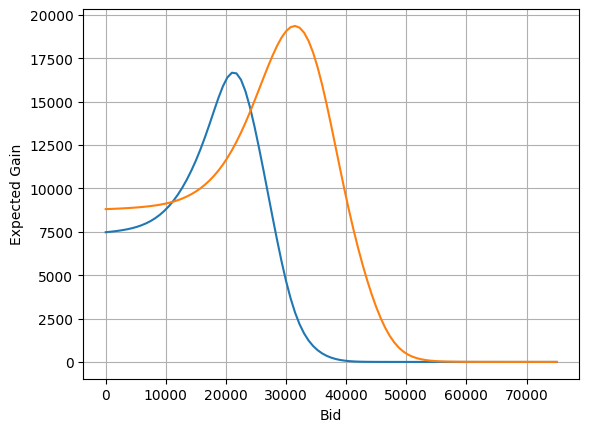

In [257]:
calc1 = GainCalculator(player1, player2)
calc2 = GainCalculator(player2, player1)

bids, gains = calc1.ExpectedGains()

plt.plot(bids, gains, label='Player 1')

print('Player 1 optimal bid', max(zip(gains, bids)))

bids, gains = calc2.ExpectedGains()
plt.plot(bids, gains, label='Player 2')

print('Player 2 optimal bid', max(zip(gains, bids)))

plt.xlabel('Bid')
plt.ylabel('Expected Gain')
plt.grid(True)